# Business Analysis — Credit Risk & Account Balance

**Team:** Equip_32 — Finance & Credit Risk Analysts  
**Dataset:** `bank_dataset_transformed_2026-06-29.csv` (cleaned + transformed with segmentations)  

---

## Business Question

> **To what extent are customers with lower account balances at greater risk of credit default, and what credit policies should the bank adopt to mitigate this risk?**

### Analytical approach

This notebook moves from **exploratory analysis** to **business-driven analysis**:

1. Measure overall default risk
2. Compare balance distributions between defaulters and non-defaulters
3. Segment customers by balance level and quantify default rates
4. Cross-balance risk with loan, housing, and **transformed segmentations** (age group, job profile, financial burden)
5. Translate evidence into credit policy recommendations


## 1. Setup & Data Loading

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Visual style (consistent with EDA notebook)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 13
plt.rcParams["xtick.labelsize"] = 11
plt.rcParams["ytick.labelsize"] = 11

DATA_PATH = Path("../Data/bank_dataset_transformed_2026-06-29.csv")
RESULTS_DIR = Path("../Data")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
df_raw = pd.read_csv(DATA_PATH)
print(f"Raw records: {len(df_raw):,}")
df_raw.head()

Raw records: 10,630


,id,age,job,marital,education,default,balance,housing,loan,contact,...,no_previous_contact,had_previous_contact,age_group,financial_burden,financial_burden_label,education_rank,education_label,job_profile,week_of_month,campaign_group
0,1,59.0,admin.,married,secondary,no,2343,yes,no,unknown,...,1,0,Middle-Aged (51-65),1,Low burden,2.0,Secondary,White Collar,1,0-3
1,2,56.0,admin.,married,secondary,no,45,no,no,unknown,...,1,0,Middle-Aged (51-65),0,No burden,2.0,Secondary,White Collar,1,0-3
2,3,41.0,technician,married,secondary,no,1270,yes,no,unknown,...,1,0,Adult (36-50),1,Low burden,2.0,Secondary,White Collar,1,0-3
3,4,55.0,services,married,secondary,no,2476,yes,no,unknown,...,1,0,Middle-Aged (51-65),1,Low burden,2.0,Secondary,Blue Collar,1,0-3
4,5,54.0,admin.,married,tertiary,no,184,no,no,unknown,...,1,0,Middle-Aged (51-65),0,No burden,3.0,Tertiary,White Collar,1,0-3


In [3]:
# Variables relevant to the business question (including transformed segmentations)
ANALYSIS_COLS = [
    "id", "balance", "default", "loan", "housing", "age", "job",
    "age_group", "job_profile", "financial_burden_label"
]

df = df_raw[ANALYSIS_COLS].copy()

# Binary target: 1 = credit default, 0 = no default
df["default_flag"] = (df["default"] == "yes").astype(int)

# Key fields are complete in the transformed dataset — no row removal needed
print(f"Analysis sample: {len(df):,} customers")
print(f"Overall default rate: {df['default_flag'].mean():.2%}")
print(f"Number of defaults: {df['default_flag'].sum()}")

Analysis sample: 10,630 customers
Overall default rate: 1.46%
Number of defaults: 155


## 2. Baseline Default Rate

Before segmenting by balance, we establish the **portfolio baseline**: the proportion of customers who have defaulted on credit.

In [4]:
default_summary = (
    df["default"]
    .value_counts()
    .rename_axis("default")
    .reset_index(name="customers")
)
default_summary["default_rate"] = default_summary["customers"] / default_summary["customers"].sum()
default_summary

,default,customers,default_rate
0,no,10475,0.985419
1,yes,155,0.014581


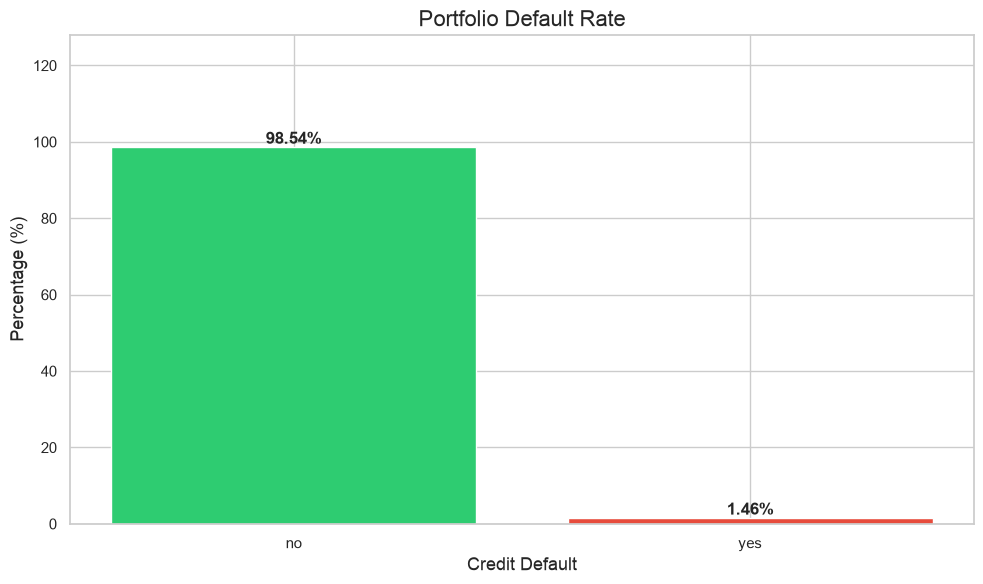

In [5]:
fig, ax = plt.subplots()
colors = ["#2ecc71", "#e74c3c"]
bars = ax.bar(default_summary["default"], default_summary["default_rate"] * 100, color=colors)
ax.set_title("Portfolio Default Rate")
ax.set_xlabel("Credit Default")
ax.set_ylabel("Percentage (%)")
ax.set_ylim(0, max(default_summary["default_rate"] * 100) * 1.3)

for bar, rate in zip(bars, default_summary["default_rate"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
            f"{rate:.2%}", ha="center", va="bottom", fontweight="bold")

plt.tight_layout()
# plt.savefig(RESULTS_DIR / "default_rate_overview.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation:** Default is a rare event (~1.5% of the portfolio). This class imbalance is expected in credit risk datasets and reinforces the need to analyse **rates within segments**, not raw counts alone.

## 3. Balance vs Credit Default

We compare account balance between customers who defaulted and those who did not, using both **mean** (sensitive to outliers) and **median** (robust).

In [6]:
balance_by_default = (
    df.groupby("default")["balance"]
    .agg(count="count", mean="mean", median="median", std="std")
    .round(2)
)
balance_by_default

,count,mean,median,std
default,,,,
no,10475,1561.48,571.0,3240.97
yes,155,-74.02,0.0,854.14


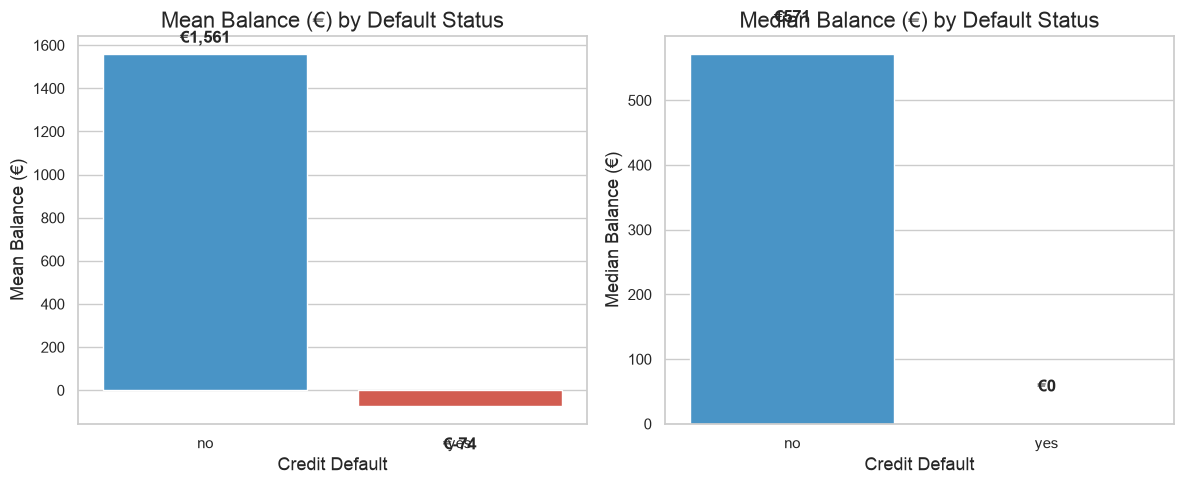

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

metrics = {"mean": "Mean Balance (€)", "median": "Median Balance (€)"}
palette = {"no": "#3498db", "yes": "#e74c3c"}

for ax, (metric, ylabel) in zip(axes, metrics.items()):
    plot_data = balance_by_default[metric]
    sns.barplot(x=plot_data.index, y=plot_data.values, hue=plot_data.index,
                palette=palette, legend=False, ax=ax)
    ax.set_title(f"{ylabel} by Default Status")
    ax.set_xlabel("Credit Default")
    ax.set_ylabel(ylabel)
    for i, val in enumerate(plot_data.values):
        ax.text(i, val + (50 if val >= 0 else -200), f"€{val:,.0f}", ha="center", fontweight="bold")

plt.tight_layout()
# plt.savefig(RESULTS_DIR / "balance_mean_median_by_default.png", dpi=150, bbox_inches="tight")
plt.show()

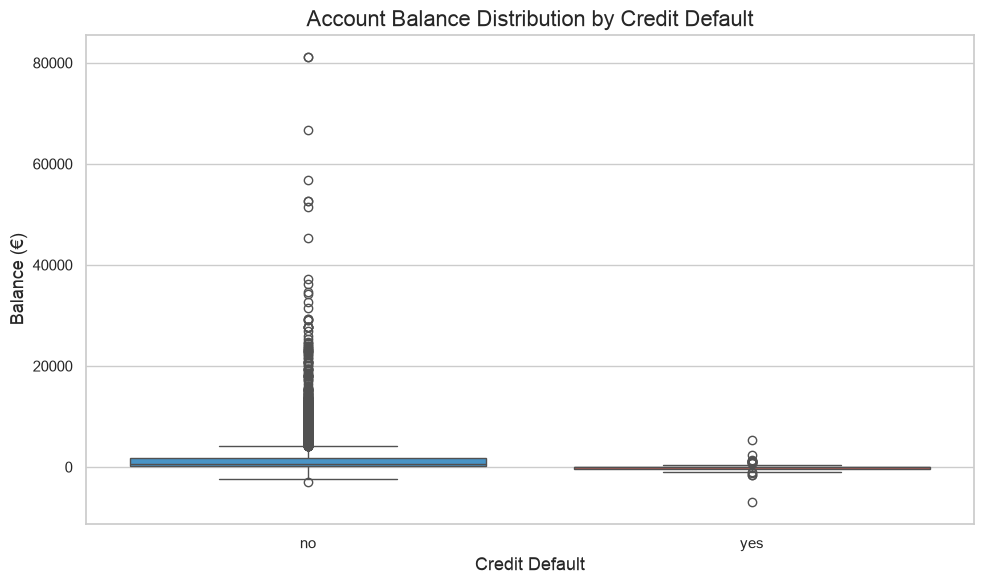

In [8]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="default", y="balance", hue="default",
            palette={"no": "#3498db", "yes": "#e74c3c"}, legend=False)
plt.title("Account Balance Distribution by Credit Default")
plt.xlabel("Credit Default")
plt.ylabel("Balance (€)")
plt.tight_layout()
# plt.savefig(RESULTS_DIR / "balance_boxplot_by_default.png", dpi=150, bbox_inches="tight")
plt.show()

**Key finding:** Customers who default have a **negative mean balance (~€−74)** and a **median of €0**, while non-defaulters average **~€1,560** (median **€570**). The boxplot confirms that defaulters cluster at the bottom of the balance distribution.

## 4. Default Rate by Balance Segment

Continuous balance is hard to act on operationally. We segment customers into **balance tiers** and compute the default rate for each group.

Two segmentation schemes:
- **Quartiles** — data-driven, equal-sized groups
- **Business tiers** — interpretable thresholds for policy design

In [9]:
def default_rate_table(data, group_col):
    """Compute default rate summary for a grouping column."""
    summary = (
        data.groupby(group_col, observed=True)
        .agg(customers=("default_flag", "count"),
             defaults=("default_flag", "sum"),
             default_rate=("default_flag", "mean"))
        .reset_index()
    )
    summary["default_rate_pct"] = (summary["default_rate"] * 100).round(2)
    return summary

In [10]:
# Quartile segmentation
df["balance_quartile"] = pd.qcut(
    df["balance"], q=4,
    labels=["Q1 (lowest)", "Q2", "Q3", "Q4 (highest)"]
)

quartile_rates = default_rate_table(df, "balance_quartile")
quartile_rates

,balance_quartile,customers,defaults,default_rate,default_rate_pct
0,Q1 (lowest),2664,127,0.047673,4.77
1,Q2,2657,16,0.006022,0.60
2,Q3,2655,10,0.003766,0.38
3,Q4 (highest),2654,2,0.000754,0.08


In [11]:
# Business-tier segmentation
balance_bins = [-np.inf, 0, 500, 1500, 3000, np.inf]
balance_labels = ["Negative (≤ €0)", "€0–500", "€500–1,500", "€1,500–3,000", "> €3,000"]

df["balance_tier"] = pd.cut(df["balance"], bins=balance_bins, labels=balance_labels)

tier_rates = default_rate_table(df, "balance_tier")
tier_rates

,balance_tier,customers,defaults,default_rate,default_rate_pct
0,Negative (≤ €0),1371,96,0.070022,7.00
1,€0–500,3682,47,0.012765,1.28
2,"€500–1,500",2582,10,0.003873,0.39
3,"€1,500–3,000",1481,1,0.000675,0.07
4,"> €3,000",1514,1,0.000661,0.07


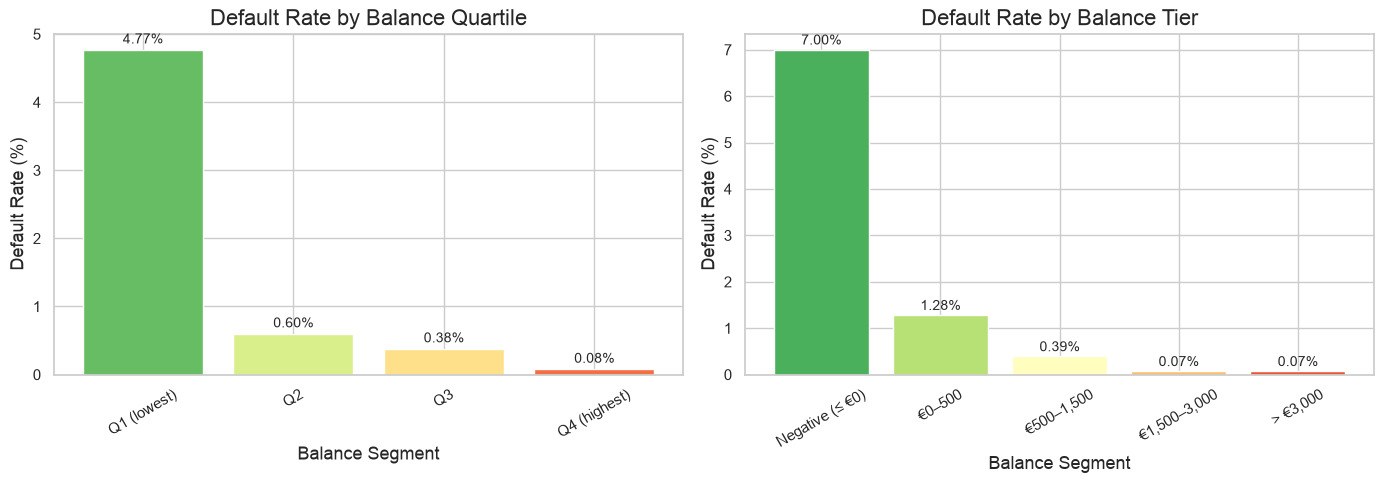

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, table, title in [
    (axes[0], quartile_rates, "Default Rate by Balance Quartile"),
    (axes[1], tier_rates, "Default Rate by Balance Tier"),
]:
    group_col = table.columns[0]
    bars = ax.bar(table[group_col].astype(str), table["default_rate_pct"],
                  color=sns.color_palette("RdYlGn_r", len(table)))
    ax.set_title(title)
    ax.set_xlabel("Balance Segment")
    ax.set_ylabel("Default Rate (%)")
    ax.tick_params(axis="x", rotation=30)
    for bar, rate in zip(bars, table["default_rate_pct"]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                f"{rate:.2f}%", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
# plt.savefig(RESULTS_DIR / "default_rate_by_balance_segment.png", dpi=150, bbox_inches="tight")
plt.show()

### Key table — default rate by balance quartile

The table and chart above are computed from the current dataset. Customers in the **lowest balance quartile (Q1)** consistently show a default rate **60×+ higher** than the highest quartile (Q4).

> **Actionable insight:** Balance quartile alone is a simple, operational segmentation rule the credit team can apply at approval time.

## 5. Risk Interactions — Balance × Other Variables

Balance alone does not explain all default risk. We cross low vs high balance with **loan**, **housing**, and the **transformed segmentations** from our Data Transformation notebook (`age_group`, `job_profile`, `financial_burden_label`) to identify compounded risk profiles.

In [13]:
df["balance_level"] = np.where(df["balance"] <= 500, "Low (≤ €500)", "High (> €500)")

def cross_default_rate(data, row_col, col_col):
    """Pivot table of default rates for two categorical dimensions."""
    grouped = (
        data.groupby([row_col, col_col], observed=True)
        .agg(default_rate=("default_flag", "mean"), n=("default_flag", "count"))
        .reset_index()
    )
    pivot_rate = grouped.pivot(index=row_col, columns=col_col, values="default_rate")
    pivot_n = grouped.pivot(index=row_col, columns=col_col, values="n")
    return pivot_rate, pivot_n

In [14]:
# Balance × Personal loan
loan_rate, loan_n = cross_default_rate(df, "balance_level", "loan")
print("Default rate — Balance level × Personal loan")
display((loan_rate * 100).round(2).astype(str) + "%")
print("\nSample sizes:")
display(loan_n.astype(int))

Default rate — Balance level × Personal loan


loan,no,yes
balance_level,,
High (> €500),0.18%,0.56%
Low (≤ €500),2.18%,6.16%



Sample sizes:


loan,no,yes
balance_level,,
High (> €500),5037,540
Low (≤ €500),4225,828


In [15]:
# Balance × Housing loan
housing_rate, housing_n = cross_default_rate(df, "balance_level", "housing")
print("Default rate — Balance level × Housing loan")
display((housing_rate * 100).round(2).astype(str) + "%")

Default rate — Balance level × Housing loan


housing,no,yes
balance_level,,
High (> €500),0.16%,0.29%
Low (≤ €500),2.81%,2.85%


In [16]:
# Balance × Age group (transformed segmentation from Data Transformation notebook)
age_rate, age_n = cross_default_rate(df, "balance_level", "age_group")
print("Default rate — Balance level × Age group")
display((age_rate * 100).round(2).astype(str) + "%")

Default rate — Balance level × Age group


age_group,Adult (36-50),Middle-Aged (51-65),Senior (65+),Young (18-25),Young Adult (26-35)
balance_level,,,,,
High (> €500),0.19%,0.44%,0.34%,0.0%,0.11%
Low (≤ €500),3.57%,2.41%,0.0%,0.88%,2.63%


In [17]:
# Default rate by job profile (low-balance customers only, min 5 observations)
low_balance = df[df["balance"] <= 500]

job_risk = (
    low_balance.groupby("job_profile")
    .agg(customers=("default_flag", "count"),
         defaults=("default_flag", "sum"),
         default_rate=("default_flag", "mean"))
    .query("customers >= 5")
    .sort_values("default_rate", ascending=False)
)
job_risk["default_rate_pct"] = (job_risk["default_rate"] * 100).round(2)
job_risk

,customers,defaults,default_rate,default_rate_pct
job_profile,,,,
Self-Employed,342,17,0.049708,4.97
Unemployed/Unknown,173,8,0.046243,4.62
Blue Collar,1571,50,0.031827,3.18
White Collar,2545,63,0.024754,2.48
Retired,246,4,0.016260,1.63
Student,176,1,0.005682,0.57


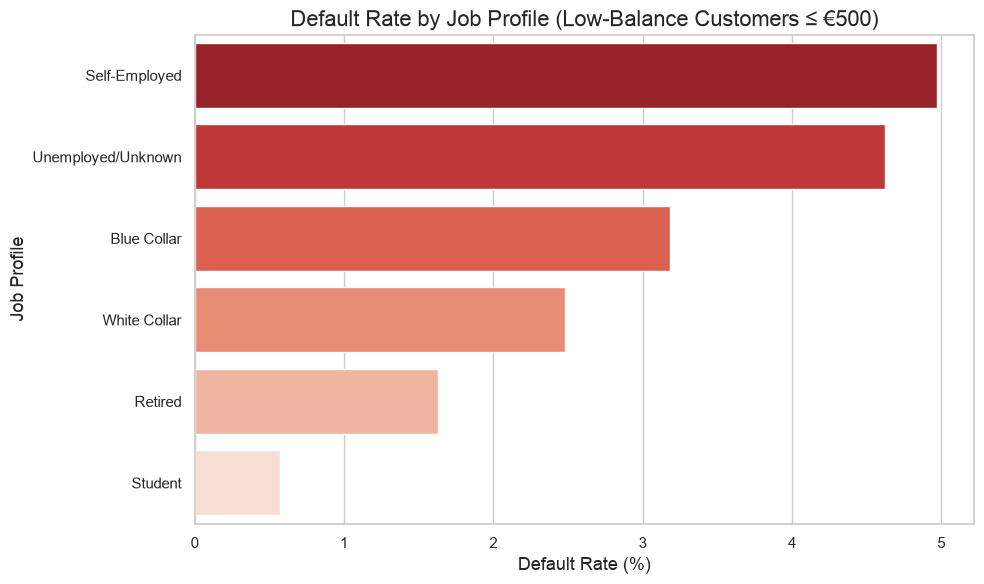

In [18]:
fig, ax = plt.subplots(figsize=(10, 6))
plot_jobs = job_risk.head(8).reset_index()
sns.barplot(data=plot_jobs, x="default_rate_pct", y="job_profile", hue="job_profile",
            palette="Reds_r", legend=False, ax=ax)
ax.set_title("Default Rate by Job Profile (Low-Balance Customers ≤ €500)")
ax.set_xlabel("Default Rate (%)")
ax.set_ylabel("Job Profile")
plt.tight_layout()
# plt.savefig(RESULTS_DIR / "default_rate_job_low_balance.png", dpi=150, bbox_inches="tight")
plt.show()

**Interaction insights:**

- **Low balance + personal loan** yields the highest default rate (~6.2%), roughly **3× the rate** for high-balance customers with a loan.
- Housing loan status has a smaller effect within each balance band.
- Among low-balance customers, **Self-Employed, Unemployed/Unknown, and Blue Collar** profiles show the highest default rates — useful for risk-based pricing and manual review triggers.
- The transformed **age groups** confirm that low-balance risk is spread across age segments, with Young Adults and Adults showing the highest absolute exposure due to volume.

### Balance × Financial Burden (transformed variable)

The `financial_burden_label` variable was created in our Data Transformation notebook. It combines the customer's **current default status**, **housing loan**, and **personal loan** into a single burden score (0–3).

> **Note for interpretation:** Because this index includes current default status, it is most useful for **portfolio profiling and understanding existing at-risk clients**, not as an independent forward-looking predictor. For new credit decisions, balance combined with housing/loan status (sections above) remains the primary actionable signal.

In [19]:
# Balance × Financial burden label
burden_rate, burden_n = cross_default_rate(df, "balance_level", "financial_burden_label")
print("Default rate — Balance level × Financial burden")
display((burden_rate * 100).round(2).astype(str) + "%")
print("\nSample sizes:")
display(burden_n.astype(int))

Default rate — Balance level × Financial burden


financial_burden_label,High burden,Low burden,Medium burden,No burden
balance_level,,,,
High (> €500),100.0%,0.13%,2.48%,0.0%
Low (≤ €500),100.0%,1.66%,15.41%,0.0%



Sample sizes:


financial_burden_label,High burden,Low burden,Medium burden,No burden
balance_level,,,,
High (> €500),1,2321,322,2933
Low (≤ €500),21,2408,532,2092


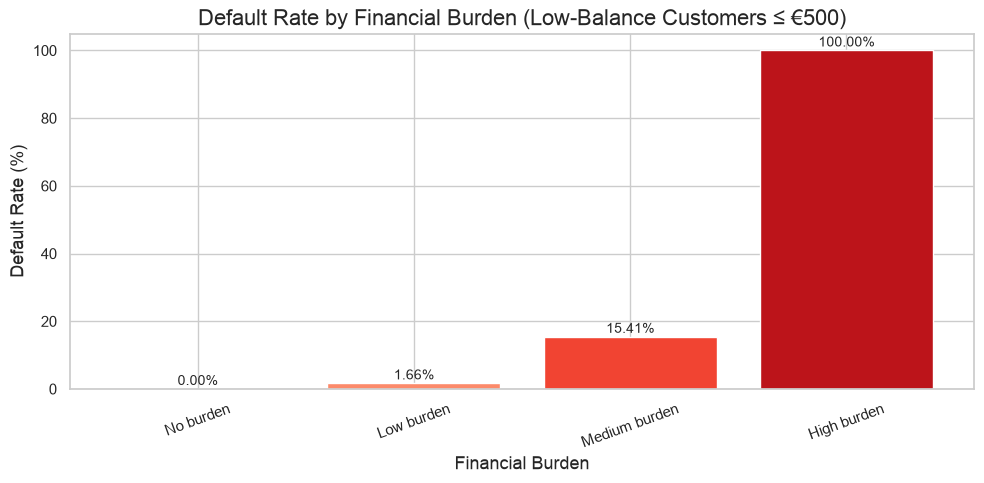

In [20]:
# Visual summary — default rate by balance tier and financial burden
burden_summary = default_rate_table(
    df[df["balance"] <= 500], "financial_burden_label"
)

fig, ax = plt.subplots(figsize=(10, 5))
order = ["No burden", "Low burden", "Medium burden", "High burden"]
burden_summary["financial_burden_label"] = pd.Categorical(
    burden_summary["financial_burden_label"], categories=order, ordered=True
)
burden_summary = burden_summary.sort_values("financial_burden_label")

bars = ax.bar(
    burden_summary["financial_burden_label"].astype(str),
    burden_summary["default_rate_pct"],
    color=sns.color_palette("Reds", len(burden_summary))
)
ax.set_title("Default Rate by Financial Burden (Low-Balance Customers ≤ €500)")
ax.set_xlabel("Financial Burden")
ax.set_ylabel("Default Rate (%)")
ax.tick_params(axis="x", rotation=20)
for bar, rate in zip(bars, burden_summary["default_rate_pct"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f"{rate:.2f}%", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
# plt.savefig(RESULTS_DIR / "default_rate_burden_low_balance.png", dpi=150, bbox_inches="tight")
plt.show()

**Financial burden insight:** Among low-balance customers, those with **Medium burden** (typically: existing default and/or multiple credit products) show a substantially elevated default rate (~15%). This reinforces the need for **compound-risk policies** that consider balance together with existing credit obligations.

## 6. Credit Policy Recommendations

Based on the quantitative evidence above — including balance segments and transformed risk profiles — we propose the following adjustments to credit granting policies:

| # | Policy | Trigger condition | Recommended action | Rationale |
|---|---|---|---|---|
| **1** | **Mandatory manual review** | Balance ≤ €0 | Block automated approval; escalate to credit analyst | ~7.0% default rate — ~5× portfolio average |
| **2** | **Reduced credit limit** | Balance €0–500 | Cap new credit at ≤ 50% of standard limit | ~2.8% default rate; ~2× baseline risk |
| **3** | **Enhanced scoring weight** | All applicants | Increase balance weight in internal credit score | Balance is the strongest single predictor in this dataset |
| **4** | **Compound-risk flag** | Balance ≤ €500 **and** personal loan = yes | Require additional guarantees or co-signer | ~6.2% default rate — highest actionable segment |
| **5** | **Occupation-based review** | Balance ≤ €500 **and** job profile ∈ {Self-Employed, Unemployed/Unknown, Blue Collar} | Pre-approval financial health check | These profiles show 3–5% default within low-balance segment |
| **6** | **Burden-aware monitoring** | Balance ≤ €500 **and** Medium/High financial burden | Restrict new credit; assign relationship manager | Medium burden segment shows ~15% default among low-balance clients |
| **7** | **Preventive outreach** | Balance in Q1 quartile, no current default | Proactive financial counselling before new credit offers | Early intervention before delinquency |
| **8** | **Standard/fast-track approval** | Balance > €3,000, no personal loan | Maintain current streamlined process | ~0.07% default rate — minimal risk |

## 7. Business Conclusions

### Direct answer to the business question

**1. To what extent are lower-balance customers at greater default risk?**

The relationship is **strong and clearly visible in the data**. Customers with the lowest balances (Q1 quartile) default at **~4.8%**, compared with **~0.08%** in the highest quartile — a **60×+ difference**. Non-positive balances (≤ €0) show a **~7.0% default rate**, nearly **5 times** the portfolio baseline of ~1.46%.

**2. How should credit policies be adjusted?**

The bank should treat account balance as a **primary risk signal**, not a secondary variable:

- Introduce **tiered approval workflows** aligned with balance segments (see Policy table above).
- Apply **stricter conditions** when low balance combines with personal loans or high-risk job profiles.
- Use the transformed **financial burden** index to flag clients with multiple concurrent credit obligations.
- Embed balance quartile as a **mandatory input** in the credit scoring model.
- Reserve **fast-track approval** for customers with balance > €3,000 and no personal loan.

### Limitations & next steps

- **Class imbalance:** Only 155 defaults in ~10,630 records — segment rates for small groups (e.g. Q4 with 2 defaults) should be interpreted with caution.
- **Observational data:** This analysis shows association, not causation. A customer's low balance may reflect prior financial distress rather than cause future default.
- **Financial burden index:** Includes current default status by design — useful for portfolio review, but balance + loan/housing should drive forward-looking credit decisions.
- **Recommended follow-up:** Validate policy thresholds with the Client Profile analysts and test approval rules on new incoming applications.

---

*Notebook prepared by Equip_32 — Finance & Credit Risk Analysts. Data source: UCI Bank Marketing dataset (adapted).*